# 公民館データ分析

####  テーマ
- 行政のオープンデータは”活用可能”なのか,分析利用できるのか
- 地域活動拠点としてPTA活動や地域活動に活用されることの多い「公民館」を軸に分析してみる

#### [1]読み込み
#### [2]前処理
- SSMSからcsv作成時による不要行の削除
#### [3]可視化
- 公民館ごとの一番近い公営住宅との距離比較
- 距離順に並び変え
#### [4]集計
- 男女別、年齢3区分別の人口と比率を集計
- グラフは一番近い公営住宅との距離順に表示

## 【読み込み】

### 1.ライブラリ読み込み

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# グラフのスタイル
plt.style.use('ggplot')
# 日本語用フォント設定
plt.rcParams["font.family"] = "Meiryo"

### 2.データ読み込み

In [33]:
# 公共施設データ
df = pd.read_csv("../data/analysis_public_facilities.csv")

### 3.データ確認

In [3]:
df.head(3)

,facility_No,facility_name,available_days,facility_area_name,housing_No,housing_name,housing_area_name,distance_m_to_nearest_housing,area,total_population,...,female_45_49,female_50_54,female_55_59,female_60_64,female_65_69,female_70_74,female_75_79,female_80_84,female_85_89,female_90_plus
0,78,盛岡市上田公民館,火水木金土日,上田,10.0,前九年アパート,前九年,1525.622140,上田,4261.0,...,135.0,167.0,141.0,154.0,123.0,106.0,130.0,89.0,83.0,90.0
1,77,盛岡市中央公民館,火水木金土日,愛宕町,11.0,つつじが丘住宅,つつじが丘,2036.267547,愛宕町,957.0,...,43.0,56.0,44.0,38.0,21.0,35.0,36.0,24.0,16.0,19.0
2,90,盛岡市薮川地区公民館,火水木金土日,薮川字外山,11.0,つつじが丘住宅,つつじが丘,14161.198793,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail(3)

,facility_No,facility_name,available_days,facility_area_name,housing_No,housing_name,housing_area_name,distance_m_to_nearest_housing,area,total_population,...,female_45_49,female_50_54,female_55_59,female_60_64,female_65_69,female_70_74,female_75_79,female_80_84,female_85_89,female_90_plus
13,81,盛岡市西部公民館,火水木金土日,南青山町,7.0,青山一丁目アパ−ト,青山,254.341376,南青山町,1596.0,...,73.0,68.0,65.0,49.0,53.0,67.0,57.0,48.0,56.0,50.0
14,(14 行に影響しました),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,完了時刻: 2026-05-27T11:28:02.0978319+09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# サイズ確認
print(df.shape)

(16, 50)


## 【前処理】

### 1.不要行削除

In [6]:
#### SSMSで出力結果が区切られておらず、1列になっていた
#### 　→　「コンマ区切り」に設定変更したことで解決
#### 以下2つの操作が不要に

In [7]:
##【パターン１】
#　0行目を削除して、インデックス振り直し
# df = df.drop(0).reset_index(drop=True)

In [8]:
##【パターン２】
# 1行目以降をスライス、インデックス振り直し
#df = df.iloc[1:].reset_index(drop=True)

#### 【後ろ2行】SQL Serverの実行結果であり、不要

In [9]:
# 確認してみる
df.tail(3)

,facility_No,facility_name,available_days,facility_area_name,housing_No,housing_name,housing_area_name,distance_m_to_nearest_housing,area,total_population,...,female_45_49,female_50_54,female_55_59,female_60_64,female_65_69,female_70_74,female_75_79,female_80_84,female_85_89,female_90_plus
13,81,盛岡市西部公民館,火水木金土日,南青山町,7.0,青山一丁目アパ−ト,青山,254.341376,南青山町,1596.0,...,73.0,68.0,65.0,49.0,53.0,67.0,57.0,48.0,56.0,50.0
14,(14 行に影響しました),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,完了時刻: 2026-05-27T11:28:02.0978319+09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# 後ろ2行をそれぞれlistで表示
print(df.iloc[-1].tolist())
print(df.iloc[-2].tolist())

['完了時刻: 2026-05-27T11:28:02.0978319+09:00', nan, nan, nan, np.float64(nan), nan, nan, np.float64(nan), nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
['(14 行に影響しました)', nan, nan, nan, np.float64(nan), nan, nan, np.float64(nan), nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(

In [11]:
# 後ろ2行前をスライス、インデックス振り直し
df = df.iloc[:-2].reset_index(drop=True)

In [12]:
# 確認
df.tail(2)

,facility_No,facility_name,available_days,facility_area_name,housing_No,housing_name,housing_area_name,distance_m_to_nearest_housing,area,total_population,...,female_45_49,female_50_54,female_55_59,female_60_64,female_65_69,female_70_74,female_75_79,female_80_84,female_85_89,female_90_plus
12,83,盛岡市松園地区公民館,月火水木金土日,東松園,2.0,岩脇緑が丘住宅,岩脇町,2069.572058,東松園,2632.0,...,81.0,97.0,82.0,84.0,101.0,131.0,207.0,136.0,70.0,42.0
13,81,盛岡市西部公民館,火水木金土日,南青山町,7.0,青山一丁目アパ−ト,青山,254.341376,南青山町,1596.0,...,73.0,68.0,65.0,49.0,53.0,67.0,57.0,48.0,56.0,50.0


In [13]:
# サイズ確認
print(df.shape)

(14, 50)


## 【可視化】

In [14]:
# カラム名取得
columns = df.columns.str.strip()
#df.columns[-3:].tolist()
print(columns)

Index(['facility_No', 'facility_name', 'available_days', 'facility_area_name',
       'housing_No', 'housing_name', 'housing_area_name',
       'distance_m_to_nearest_housing', 'area', 'total_population',
       'male_population', 'female_population', 'male_0_4', 'male_5_9',
       'male_10_14', 'male_15_19', 'male_20_24', 'male_25_29', 'male_30_34',
       'male_35_39', 'male_40_44', 'male_45_49', 'male_50_54', 'male_55_59',
       'male_60_64', 'male_65_69', 'male_70_74', 'male_75_79', 'male_80_84',
       'male_85_89', 'male_90_plus', 'female_0_4', 'female_5_9',
       'female_10_14', 'female_15_19', 'female_20_24', 'female_25_29',
       'female_30_34', 'female_35_39', 'female_40_44', 'female_45_49',
       'female_50_54', 'female_55_59', 'female_60_64', 'female_65_69',
       'female_70_74', 'female_75_79', 'female_80_84', 'female_85_89',
       'female_90_plus'],
      dtype='str')


### 1.公民館ごとに一番近い公営住宅までの距離比較

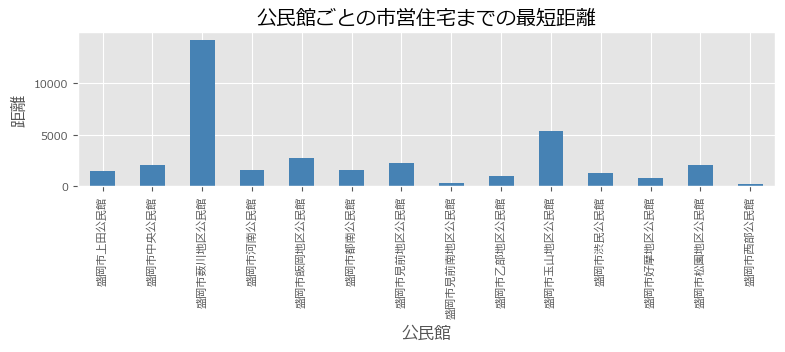

In [15]:
df.plot(
    x="facility_name",
    y="distance_m_to_nearest_housing",
    kind="bar",
    figsize=(9, 2),
    fontsize=8,
    title="公民館ごとの市営住宅までの最短距離",
    color="steelblue",
    legend=False
)

plt.xlabel("公民館", fontsize=12)
plt.ylabel("距離", fontsize=12)

plt.show()

#### 所感

- 「薮川地区公民館」は一番近い公営住宅から10km以上離れている
- 　→　薮川地区には公営住宅はなく、近隣にも公営住宅があるような地域がない
- 「玉山地区公民館」は一番近い公営住宅から5kmほど
- 　→　これも玉山地区以外の地域の公営住宅を拾っている可能性

In [16]:
# 距離順に並び変え
sorted_df = df.sort_values("distance_m_to_nearest_housing", ascending=False)
sorted_df[["facility_name", "distance_m_to_nearest_housing", "housing_name", 'facility_area_name', "housing_area_name","area"]]

,facility_name,distance_m_to_nearest_housing,housing_name,facility_area_name,housing_area_name,area
2,盛岡市薮川地区公民館,14161.198793,つつじが丘住宅,薮川字外山,つつじが丘,NaN
9,盛岡市玉山地区公民館,5310.833892,渋民団地,日戸字鷹高,渋民字大前田,NaN
4,盛岡市飯岡地区公民館,2758.713220,仙北西アパート,下飯岡,西仙北,下飯岡
6,盛岡市見前地区公民館,2265.134495,見前アパート,津志田中央,東見前,津志田中央
12,盛岡市松園地区公民館,2069.572058,岩脇緑が丘住宅,東松園,岩脇町,東松園
1,盛岡市中央公民館,2036.267547,つつじが丘住宅,愛宕町,つつじが丘,愛宕町
3,盛岡市河南公民館,1546.762097,川目アパート,松尾町,東山,松尾町
5,盛岡市都南公民館,1535.108902,見前アパート,永井,東見前,永井
0,盛岡市上田公民館,1525.622140,前九年アパート,上田,前九年,上田
10,盛岡市渋民公民館,1310.043259,渋民団地,渋民字鶴塚,渋民字大前田,NaN


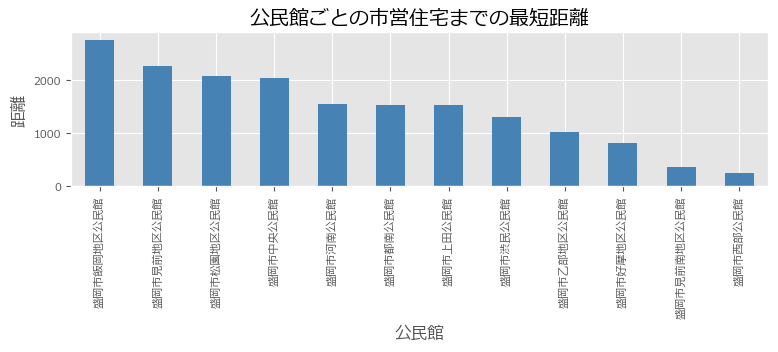

In [39]:
## 薮川地区は10km以上、玉山地区も5km以上距離があるため、除外して再比較
df_distance_under_5000 = sorted_df.query('distance_m_to_nearest_housing < 5000')
df_distance_under_5000.plot(
    x="facility_name",
    y="distance_m_to_nearest_housing",
    kind="bar",
    figsize=(9, 2),
    fontsize=8,
    title="公民館ごとの市営住宅までの最短距離",
    color="steelblue",
    legend=False
)

plt.xlabel("公民館", fontsize=12)
plt.ylabel("距離", fontsize=12)

# 画像保存
plt.savefig('../output/public_facilities/distance_m_to_nearest_housing_bar.png', bbox_inches='tight')

plt.show()

#### 所感

- 【外れ値】「薮川地区公民館」は「つつじヶ丘住宅」と紐づいていた
- 　　　　　　→　「つつじヶ丘」が約2kmに「中央公民館」がある
- 【外れ値】「玉山地区公民館」は「渋民団地」と紐づいていた
- 　　　　　　→　「渋民団地」は1.5km以内に「渋民公民館」あり
- 「西部公民館」「見前南地区公民館	」はともに400m以内に公営住宅がある
- 外れ値を除くと全体的に約2km以内には公営住宅がある場所に公民館が設置されている
- 「飯岡地区公民館」に一番近い公営住宅は「仙北西アパート」だが3km離れている
- 　→　「仙北」は子育て地域であり住宅街も多いのになぜ？
- 　　　　→　仙北には「活動センター」が存在していた（ネット検索）
- 「見前地区公民館」も一番近い公営住宅と2kmちょっと離れているが、「都南公民館」と同じ公営住宅と紐づいている

## 【集計】

In [18]:
# 人口データと結合できなかった公民館を除外
dropna_df = df.dropna(subset=['total_population'])
dropna_df.shape

(10, 50)

In [19]:
# 男性の人口カラム抽出
male_cols = [col for col in df.columns 
             if "male" in col
             and "population" not in col
             and "female" not in col
            ]
# 女性の人口カラム抽出
female_cols = [col for col in df.columns 
               if "female" in col
               and "population" not in col
              ]

In [20]:
# 年齢ごとの人口データを男女別、総人口算出
dropna_df["男性人口"] = dropna_df[male_cols].sum(axis=1)
dropna_df["女性人口"] = dropna_df[female_cols].sum(axis=1)
dropna_df["総人口"] = dropna_df["男性人口"] + dropna_df["女性人口"]

In [21]:
# 集計結果と元々集計されたカラムが一致しているかチェック
print("総人口 ：",(dropna_df["total_population"] == dropna_df["総人口"]).all())
print("男性人口 ：",(dropna_df["male_population"] == dropna_df["男性人口"]).all())
print("女性人口 ：",(dropna_df["female_population"] == dropna_df["女性人口"]).all())

総人口 ： True
男性人口 ： True
女性人口 ： True


In [22]:
# 年齢3区分別（15歳未満人口、15～64歳人口、65歳以上人口）※総務省統計局より
# カラムリスト
male_under_15_cols = ["male_0_4","male_5_9","male_10_14"]
male_15_64_cols = ["male_15_19","male_20_24","male_25_29",'male_30_34',
                   'male_35_39','male_40_44','male_45_49','male_50_54','male_55_59','male_60_64']
male_65_plus_cols =['male_65_69','male_70_74','male_75_79','male_80_84','male_85_89','male_90_plus']
female_under_15_cols = ['female_0_4', 'female_5_9','female_10_14']
female_15_64_cols = ['female_15_19', 'female_20_24', 'female_25_29','female_30_34', 
                     'female_35_39', 'female_40_44', 'female_45_49','female_50_54', 'female_55_59', 'female_60_64']
female_65_plus_cols =['female_65_69', 'female_70_74', 'female_75_79', 'female_80_84', 'female_85_89','female_90_plus']

In [23]:
# 個数確認
print("15歳以下男性カラム数  :",len(male_under_15_cols))
print("15歳-64歳男性カラム数 :",len(male_15_64_cols))
print("65歳以上男性カラム数 :",len(male_65_plus_cols))
print("合計 :",len(male_65_plus_cols)+len(male_15_64_cols)+len(male_65_plus_cols))
print("15歳以下女性性カラム数  :",len(female_under_15_cols))
print("15歳-64歳女性カラム数 :",len(female_15_64_cols))
print("65歳以上女性カラム数 :",len(female_65_plus_cols))
print("合計 :",len(female_65_plus_cols)+len(female_15_64_cols)+len(female_65_plus_cols))

15歳以下男性カラム数  : 3
15歳-64歳男性カラム数 : 10
65歳以上男性カラム数 : 6
合計 : 22
15歳以下女性性カラム数  : 3
15歳-64歳女性カラム数 : 10
65歳以上女性カラム数 : 6
合計 : 22


In [24]:
# 年齢3区分別人口集計
dropna_df["male_under_15"] = dropna_df[male_under_15_cols].sum(axis=1)
dropna_df["male_15_64"] = dropna_df[male_15_64_cols].sum(axis=1)
dropna_df["male_65_plus"] = dropna_df[male_65_plus_cols].sum(axis=1)
dropna_df["female_under_15"] = dropna_df[female_under_15_cols].sum(axis=1)
dropna_df["female_15_64"] = dropna_df[female_15_64_cols].sum(axis=1)
dropna_df["female_65_plus"] = dropna_df[female_65_plus_cols].sum(axis=1)
dropna_df["population_under_15"] = dropna_df["male_under_15"] + dropna_df["female_under_15"]
dropna_df["population_15_64"] = dropna_df["male_15_64"] + dropna_df["female_15_64"]
dropna_df["population_65_plus"] = dropna_df["male_65_plus"] + dropna_df["female_65_plus"]

In [31]:
# 人口比率(％) (pct=percent)
dropna_df["male_under_15_pct"] = dropna_df["male_under_15"] / dropna_df["male_population"] * 100
dropna_df["male_15_64_pct"] = dropna_df["male_15_64"] / dropna_df["male_population"] * 100
dropna_df["male_65_plus_pct"] = dropna_df["male_65_plus"] / dropna_df["male_population"] * 100
dropna_df["female_under_15_pct"] = dropna_df["female_under_15"] / dropna_df["female_population"] * 100
dropna_df["female_15_64_pct"] = dropna_df["female_15_64"] / dropna_df["female_population"] * 100
dropna_df["female_65_plus_pct"] = dropna_df["female_65_plus"] / dropna_df["female_population"] * 100
dropna_df["population_under_15_pct"] = dropna_df["population_under_15"] / dropna_df["total_population"] * 100
dropna_df["population_15_64_pct"] = dropna_df["population_15_64"] / dropna_df["total_population"] * 100
dropna_df["population_65_plus_pct"] = dropna_df["population_65_plus"] / dropna_df["total_population"] * 100
dropna_df["population_male_pct"] = dropna_df["male_population"] / dropna_df["total_population"]  * 100
dropna_df["population_female_pct"] = dropna_df["female_population"] / dropna_df["total_population"]  * 100

In [26]:
## 算出した比率を合計して100になるかチェック
# 浮動小数点誤差により == 100 は不安定なため isclose を使用
# 小数誤差を許容して「ほぼ」100か判定
print("男性人口割合 ：", np.isclose(dropna_df["male_under_15_pct"]+dropna_df["male_15_64_pct"]+dropna_df["male_65_plus_pct"], 100))
print("女性人口割合 ：",np.isclose(dropna_df["female_under_15_pct"]+dropna_df["female_15_64_pct"]+dropna_df["female_65_plus_pct"], 100))
print("総人口割合　 ：",np.isclose(dropna_df["population_under_15_pct"]+dropna_df["population_15_64_pct"]+dropna_df["population_65_plus_pct"], 100))
print("総人口男女比 ：",np.isclose(dropna_df["population_male_pct"]+dropna_df["population_female_pct"], 100))

男性人口割合 ： [ True  True  True  True  True  True  True  True  True  True]
女性人口割合 ： [ True  True  True  True  True  True  True  True  True  True]
総人口割合　 ： [ True  True  True  True  True  True  True  True  True  True]
総人口男女比 ： [ True  True  True  True  True  True  True  True  True  True]


In [27]:
# 市営住宅との距離が遠い順に並び替え
sorted_dropna_df = dropna_df.sort_values("distance_m_to_nearest_housing", ascending=False)
sorted_dropna_df[["facility_name", "distance_m_to_nearest_housing",
                  "population_under_15", 'population_15_64', "population_65_plus","total_population"]]

,facility_name,distance_m_to_nearest_housing,population_under_15,population_15_64,population_65_plus,total_population
4,盛岡市飯岡地区公民館,2758.713220,101.0,541.0,391.0,1033.0
6,盛岡市見前地区公民館,2265.134495,278.0,1737.0,456.0,2471.0
12,盛岡市松園地区公民館,2069.572058,216.0,1202.0,1214.0,2632.0
1,盛岡市中央公民館,2036.267547,93.0,592.0,272.0,957.0
3,盛岡市河南公民館,1546.762097,42.0,284.0,211.0,537.0
5,盛岡市都南公民館,1535.108902,1015.0,4922.0,2295.0,8232.0
0,盛岡市上田公民館,1525.622140,376.0,2846.0,1039.0,4261.0
8,盛岡市乙部地区公民館,1028.067441,158.0,1101.0,792.0,2051.0
7,盛岡市見前南地区公民館,366.193386,653.0,2976.0,1428.0,5057.0
13,盛岡市西部公民館,254.341376,162.0,910.0,524.0,1596.0


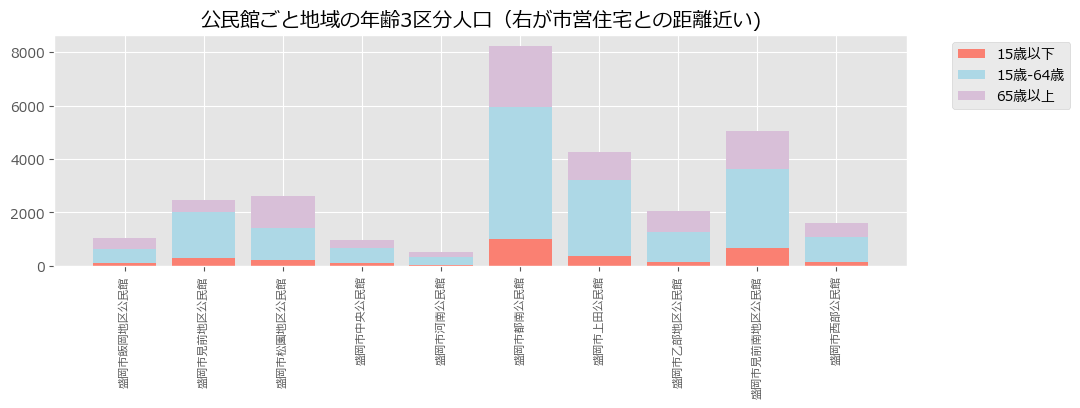

In [42]:
# 公民館別、地域の年齢3区分人口を積み上げ棒グラフ
plt.figure(figsize=(11, 3))

plt.bar(
    sorted_dropna_df["facility_name"],
    sorted_dropna_df["population_under_15"],
    label="15歳以下",
    color="salmon"
)
plt.bar(
    sorted_dropna_df["facility_name"],
    sorted_dropna_df["population_15_64"],
    bottom=sorted_dropna_df["population_under_15"],
    label="15歳-64歳",
    color="lightblue"
)
plt.bar(
    sorted_dropna_df["facility_name"],
    sorted_dropna_df["population_65_plus"],
    bottom=sorted_dropna_df["population_under_15"]+sorted_dropna_df["population_15_64"],
    label="65歳以上",
    color="thistle"
)
# x軸90度回転、フォントサイズ8
plt.xticks(rotation=90,fontsize=8)
# 凡例表示
plt.legend(bbox_to_anchor=(1.2, 1),loc='upper right')

plt.title('公民館ごと地域の年齢3区分人口（右が市営住宅との距離近い)')
# composition - 構成
plt.savefig('../output/public_facilities/age_composition_stacked_bar.png', bbox_inches='tight')
plt.show()

#### 所感

- 市営住宅との距離比較して遠い公民館5件は総人口1000人を切る地域もある
- 逆に距離が近い5件には突出した総人口8000人越えの地域もあるし、最低でも1500人を割っていない
- 「河南公民館」と「都南公民館」は一番近い公営住宅との距離は約1.5kmでほぼ同じなのに約16倍も人口差がある

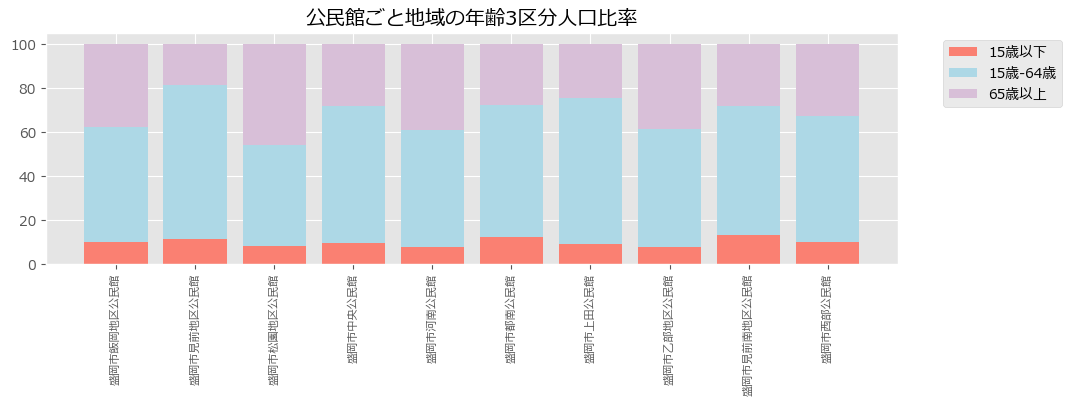

In [41]:
# 公民館別、地域の年齢3区分人口を積み上げ棒グラフ
plt.figure(figsize=(11, 3))

plt.bar(
    sorted_dropna_df["facility_name"],
    sorted_dropna_df["population_under_15_pct"],
    label="15歳以下",
    color="salmon"
)
plt.bar(
    sorted_dropna_df["facility_name"],
    sorted_dropna_df["population_15_64_pct"],
    bottom=sorted_dropna_df["population_under_15_pct"],
    label="15歳-64歳",
    color="lightblue"
)
plt.bar(
    sorted_dropna_df["facility_name"],
    sorted_dropna_df["population_65_plus_pct"],
    bottom=sorted_dropna_df["population_under_15_pct"]+sorted_dropna_df["population_15_64_pct"],
    label="65歳以上",
    color="thistle"
)
# x軸90度回転、フォントサイズ8
plt.xticks(rotation=90,fontsize=8)
# 凡例表示
plt.legend(bbox_to_anchor=(1.2, 1),loc='upper right')

plt.title('公民館ごと地域の年齢3区分人口比率')
plt.savefig('../output/public_facilities/age_composition_100percent_stacked_bar.png', bbox_inches='tight')
plt.show()

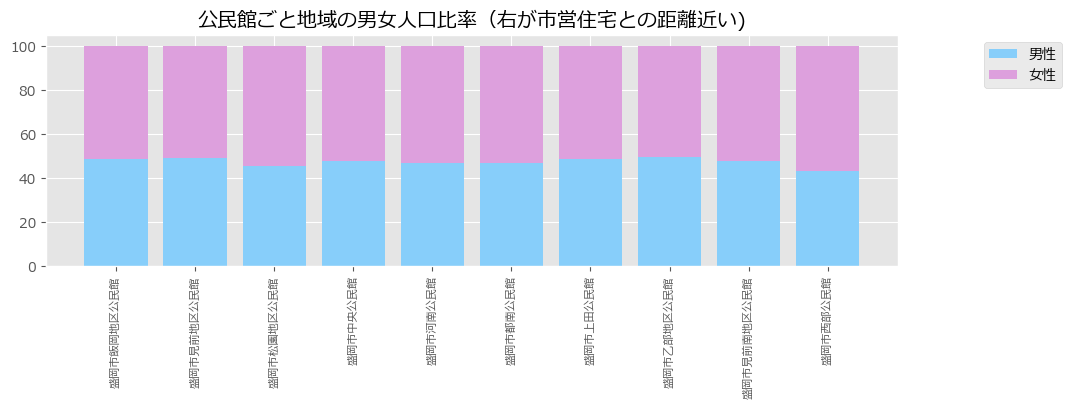

In [38]:
# 公民館別、地域の男女人口比率を積み上げ棒グラフ
plt.figure(figsize=(11, 3))

plt.bar(
    sorted_dropna_df["facility_name"],
    sorted_dropna_df["population_male_pct"],
    label="男性",
    color="lightskyblue"
)
plt.bar(
    sorted_dropna_df["facility_name"],
    sorted_dropna_df["population_female_pct"],
    bottom=sorted_dropna_df["population_male_pct"],
    label="女性",
    color="plum"
)

# x軸90度回転、フォントサイズ8
plt.xticks(rotation=90,fontsize=8)
# 凡例表示
plt.legend(bbox_to_anchor=(1.2, 1),loc='upper right')

plt.title('公民館ごと地域の男女人口比率（右が市営住宅との距離近い)')
plt.savefig('../output//public_facilities/gender_composition_100percent_stacked_bar.png', bbox_inches='tight')
plt.show()

#### 所感

- 人口比率は一番近い公営住宅との距離によって差はみられない